IMPORTS

In [87]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns   

In [88]:
df = pd.read_csv("german_credit_data.csv")

In [89]:
sns.set_style("whitegrid")

In [90]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [91]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [92]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [93]:
df.shape

(1000, 11)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [95]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [97]:
df.duplicated().sum()   

np.int64(0)

In [98]:
df.dropna().reset_index(drop=True)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [99]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [100]:
df.drop(columns = ["Unnamed: 0"], inplace=True)

In [101]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

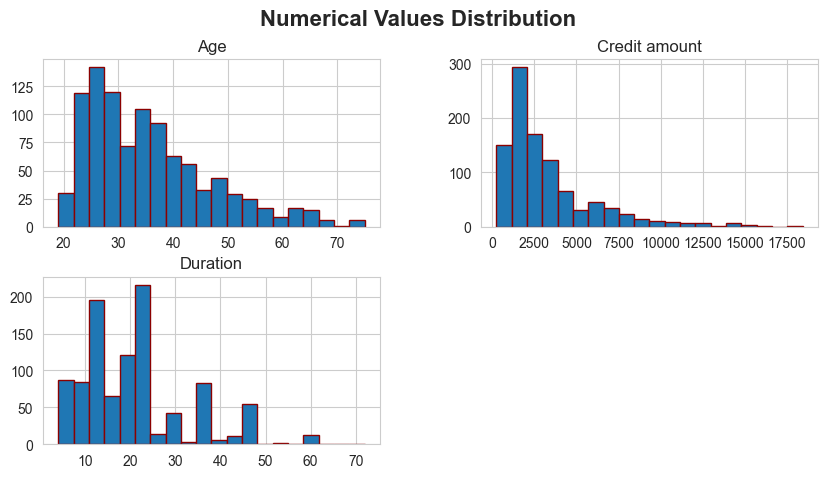

In [102]:
df[["Age","Credit amount","Duration"]].hist(figsize=(10,5), bins=20,edgecolor="darkred")
plt.suptitle("Numerical Values Distribution", fontsize=16, fontweight="bold")
plt.show()

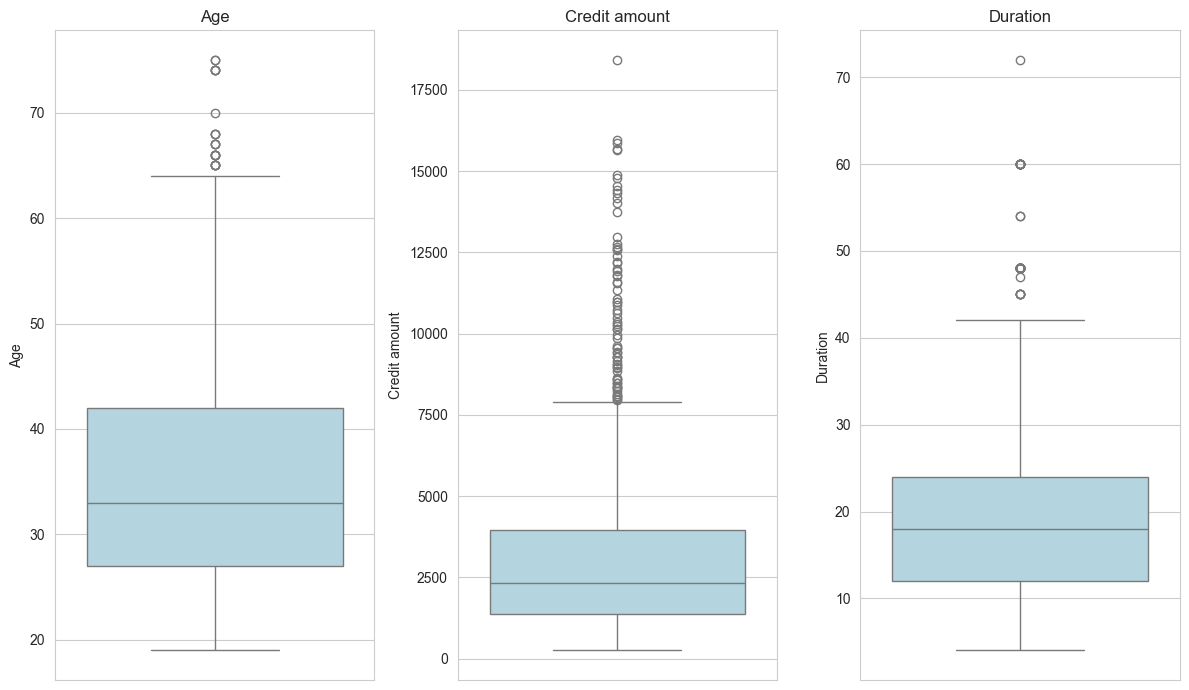

In [103]:
plt.figure(figsize=(12,7))
for index, col in enumerate(["Age","Credit amount","Duration"]):
  plt.subplot(1,3,index+1) 
  sns.boxplot(y=df[col], color="lightblue")
  plt.title(col)

plt.tight_layout()
plt.show()


In [104]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,NaN,NaN,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,42,male,3,own,little,NaN,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [105]:
categorical_col = ["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\2988040988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2",order=df[col].value_counts().index)
C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\2988040988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2",order=df[col].value_counts().index)
C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\2988040988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2",order=df[col].value_counts().index)
C

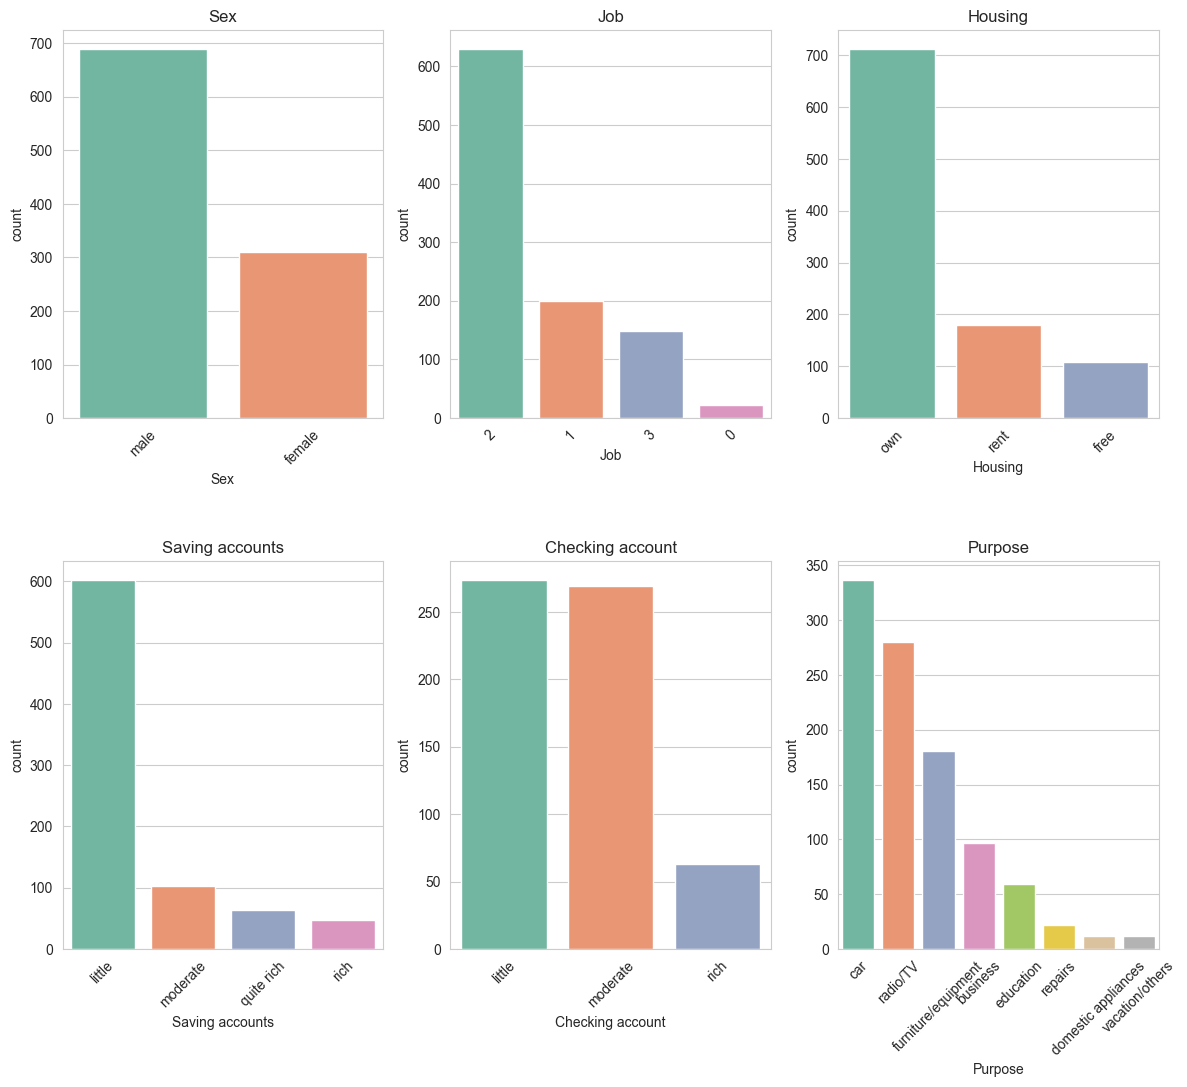

In [106]:
plt.figure(figsize=(12,15))

for index, col in enumerate(categorical_col):
  plt.subplot(3,3,index+1)
  sns.countplot(data=df, x=col, palette="Set2",order=df[col].value_counts().index)
  plt.title(col)
  plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [107]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()

In [108]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


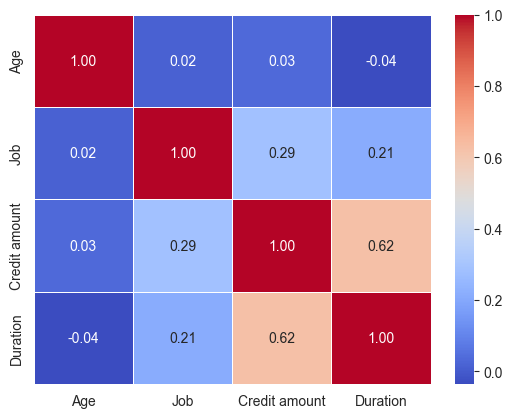

In [109]:
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5,fmt=".2f")
plt.show()

In [110]:
df.groupby("Job")["Credit amount"].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [111]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [112]:
pd.pivot_table(df,values = "Credit amount", index = "Housing", columns = "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


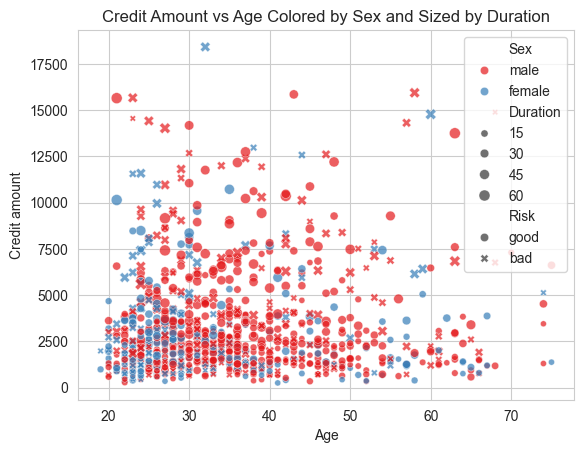

In [113]:
sns.scatterplot(data=df, x="Age", y="Credit amount", hue="Sex", palette="Set1",size="Duration", alpha=0.7,style="Risk")
plt.title("Credit Amount vs Age Colored by Sex and Sized by Duration") 
plt.show()

C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\3936670938.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


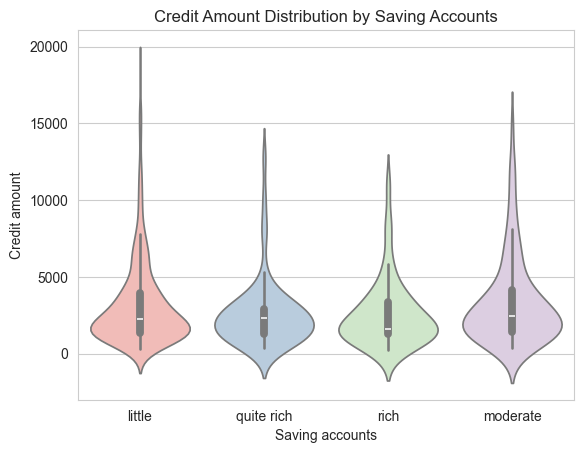

In [114]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

FEATUER ENG.

In [115]:
(df["Risk"].value_counts(normalize=True) * 100).round(2).astype(str) + "%"

Risk
good    70.0%
bad     30.0%
Name: proportion, dtype: object

C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\3884605775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x="Risk", y=col, palette="Pastel2")
C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\3884605775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x="Risk", y=col, palette="Pastel2")
C:\Users\gutku\AppData\Local\Temp\ipykernel_14100\3884605775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x="Risk", y=col, palette="Pastel2")


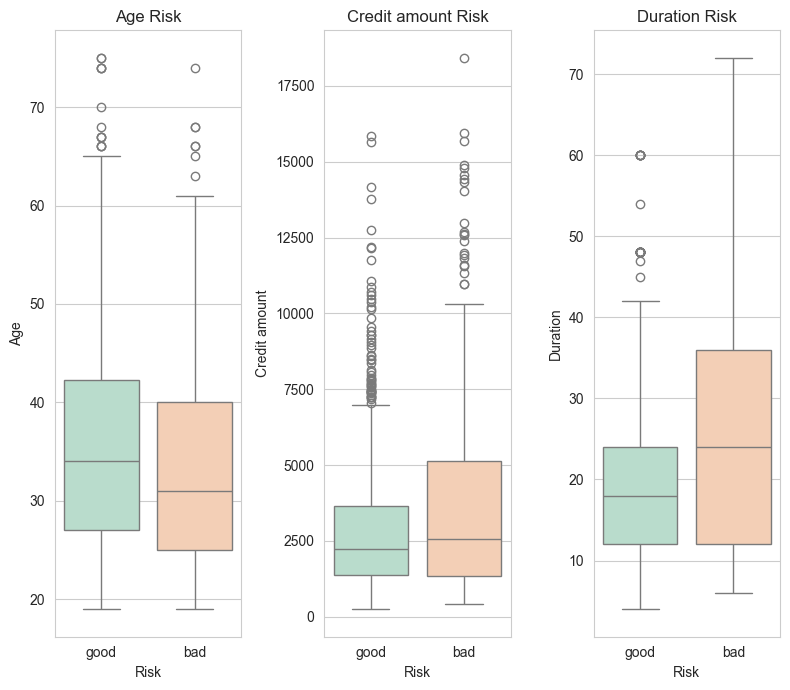

In [116]:
plt.figure(figsize=(8,7))
for i ,col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data = df, x="Risk", y=col, palette="Pastel2")
    plt.title(f"{col} Risk")
plt.tight_layout()
plt.show()

In [117]:
categorical_col

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [118]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()


,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


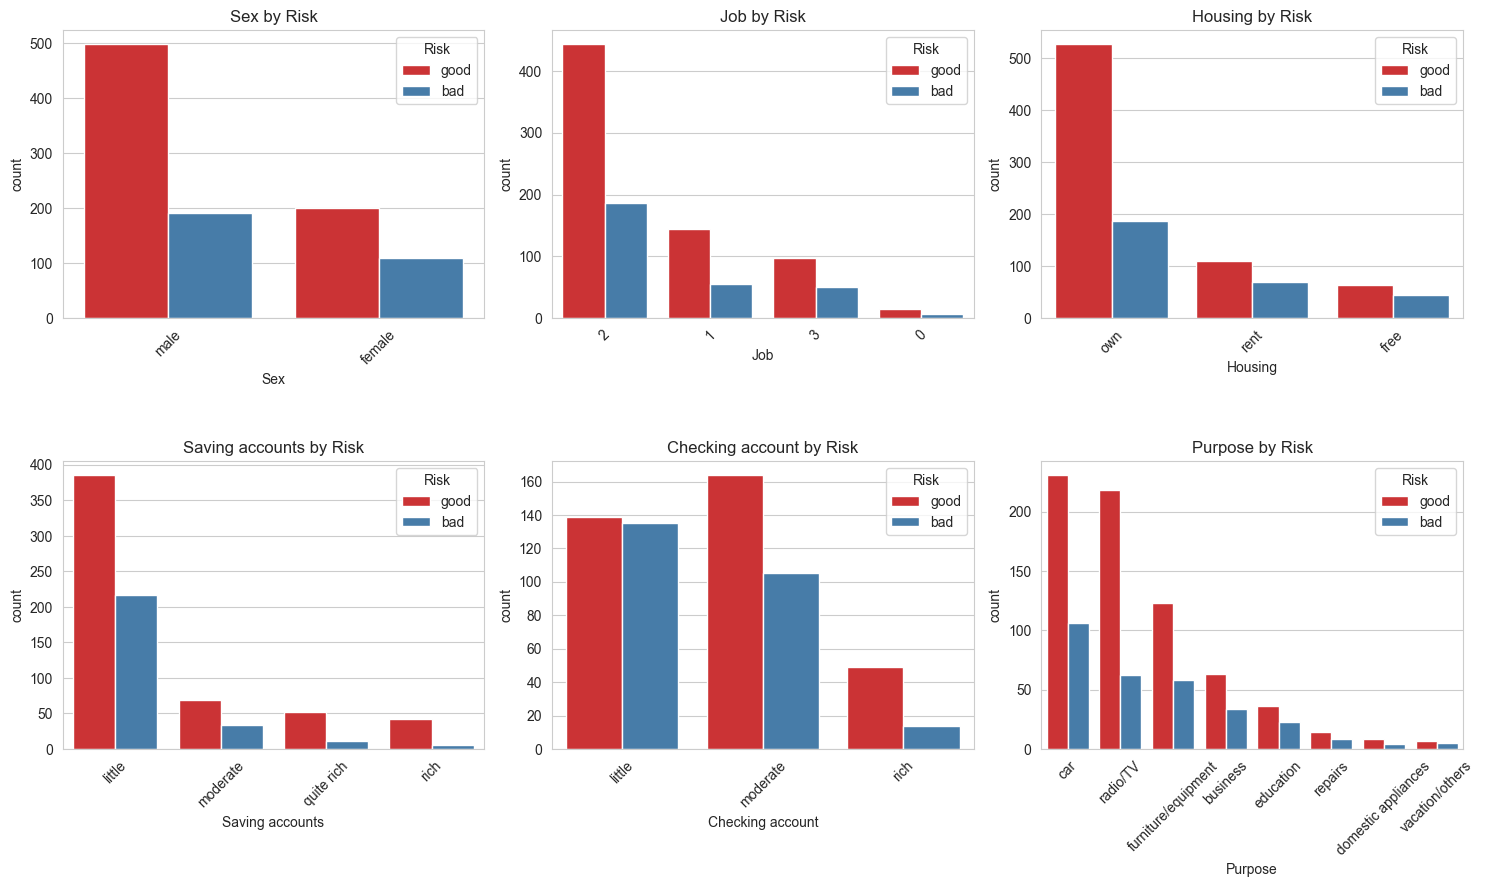

In [119]:
plt.figure(figsize=(15,12))
for i, col in enumerate(categorical_col):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, hue = "Risk", palette="Set1",order = df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [120]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [121]:
features = ["Age","Job","Credit amount","Duration","Sex","Housing","Saving accounts","Checking account"]

In [122]:
target = "Risk"

In [123]:
df_model = df[features + [target]].copy()

In [124]:
df_model.head()

,Age,Job,Credit amount,Duration,Sex,Housing,Saving accounts,Checking account,Risk
0,67,2,1169,6,male,own,NaN,little,good
1,22,2,5951,48,female,own,little,moderate,bad
2,49,1,2096,12,male,own,little,NaN,good
3,45,2,7882,42,male,free,little,little,good
4,53,2,4870,24,male,free,little,little,bad


In [125]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [126]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")   

In [127]:
le_dict = {}


In [128]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [129]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le 
    joblib.dump(le, f"{col}_encoder.pkl")


In [130]:
target

'Risk'

In [131]:
le_target = LabelEncoder()

In [132]:
df_model[target] = le_target.fit_transform(df_model[target])

In [133]:
df_model[target].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [134]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [135]:
df_model.head()

,Age,Job,Credit amount,Duration,Sex,Housing,Saving accounts,Checking account,Risk
0,67,2,1169,6,1,1,4,0,1
1,22,2,5951,48,0,1,0,1,0
2,49,1,2096,12,1,1,0,3,1
3,45,2,7882,42,1,0,0,0,1
4,53,2,4870,24,1,0,0,0,0


In [136]:
from sklearn.model_selection import train_test_split

In [137]:
X = df_model.drop(target, axis=1)

In [138]:
y = df_model[target]

In [139]:
X

,Age,Job,Credit amount,Duration,Sex,Housing,Saving accounts,Checking account
0,67,2,1169,6,1,1,4,0
1,22,2,5951,48,0,1,0,1
2,49,1,2096,12,1,1,0,3
3,45,2,7882,42,1,0,0,0
4,53,2,4870,24,1,0,0,0
...,...,...,...,...,...,...,...,...
995,31,1,1736,12,0,1,0,3
996,40,3,3857,30,1,1,0,0
997,38,2,804,12,1,1,0,3
998,23,2,1845,45,1,0,0,0


In [140]:
y

0      1
1      0
2      1
3      1
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Risk, Length: 1000, dtype: int64

In [141]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [142]:
X_train.shape

(800, 8)

In [143]:
X_test.shape

(200, 8)

In [144]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [145]:
def train_model(model,param_grid,X_train,y_train,X_test,y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [146]:
dt = DecisionTreeClassifier(random_state=1,class_weight="balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [147]:
best_dt, dt_acc, dt_best_params = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [148]:
print(f"Best Decision Tree Accuracy: {dt_acc:.4f}")

Best Decision Tree Accuracy: 0.6750


In [149]:
print("Best Parameters for Decision Tree:", dt_best_params)

Best Parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [150]:
rf = RandomForestClassifier(random_state=1,class_weight="balanced")
rf_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [151]:
best_rf, rf_acc, rf_best_params = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [152]:
print(f"Best Random Forest Accuracy: {rf_acc:.4f}")

Best Random Forest Accuracy: 0.6950


In [153]:
et = ExtraTreesClassifier(random_state=1,class_weight="balanced")
et_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [154]:
best_et, et_acc, et_best_params = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [155]:
print(f"Best Extra Trees Accuracy: {et_acc:.4f}")

Best Extra Trees Accuracy: 0.7100


In [156]:
print(f"Best params: {et_best_params}")

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [157]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train == 0).sum()/(y_train == 1).sum(), eval_metric = "logloss")

In [158]:
xgb_param_grid = {
    "n_estimators": [100,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.1,0.2],
    "subsample": [0.7,1.0],
    "colsample_bytree": [0.7,1.0]
}

In [159]:
best_xgb, xgb_acc, xgb_best_params = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [160]:
print(f"XGB accuracy: {xgb_acc:.4f}")

XGB accuracy: 0.6950


In [161]:
print(f"Best XGB params: {xgb_best_params}")

Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}


In [162]:
best_et.predict(X_test)

array([1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1])

In [163]:
joblib.dump(best_et, "best_extra_trees_model.pkl")

['best_extra_trees_model.pkl']